In [1]:
import sys
!{sys.executable} -m pip install --upgrade nbformat



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\streaming_emulator\.venv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import sys
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import plotly.io as pio

# Add project root
project_root = Path("C:/streaming_emulator")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from DTC.src.inference import DTCInferenceService
from DTC.src import config

print("Environment Ready.")
     

Environment Ready.


In [3]:
# 2024-08-01 08:16:32+00:00
# 2024-08-06 15:59:59+00:00
pio.renderers.defualt = 'iframe'

In [4]:
# --- USER INPUTS ---
SIM_ID = "sim001"
MODULE = "engine"

# We select a slice of time to analyze. 
# Note: Ensure these timestamps exist in your synthetic_engine_inference...csv file.
# You might need to check your CSV first to pick a valid range.
START_TIME = "2024-08-01 08:00:32+00:00"
END_TIME = "2024-08-01 09:00:32+00:00" # 20 minute window

print(f"Configuration: {SIM_ID} | {MODULE}")
print(f"Window: {START_TIME} -> {END_TIME}")

Configuration: sim001 | engine
Window: 2024-08-01 08:00:32+00:00 -> 2024-08-01 09:00:32+00:00


In [5]:
def load_data_window(sim_id, module, start_str, end_str):
    search_pattern = config.DATA_DIR / sim_id / f"synthetic_{module}_*.csv"
    import glob
    files = glob.glob(str(search_pattern))
    
    if not files:
        raise FileNotFoundError(f"No CSV found for {module} in {sim_id}")
    
    print(f"Reading: {files[0]}")
    df = pd.read_csv(files[0])
    
    # --- ROBUST TIME HANDLING ---
    # 1. Force the DataFrame column to UTC, handling the "+00:00" automatically
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    
    # 2. Force the Start/End inputs to UTC so they match the DataFrame
    start_ts = pd.to_datetime(start_str, utc=True)
    end_ts = pd.to_datetime(end_str, utc=True)
    
    # 3. Filter
    mask = (df['timestamp'] >= start_ts) & (df['timestamp'] <= end_ts)
    df_window = df.loc[mask].copy()
    
    return df_window

# Execute
try:
    df_window = load_data_window(SIM_ID, MODULE, START_TIME, END_TIME)
    print(f"Successfully loaded {len(df_window)} rows.")
    print("Time range in data:", df_window['timestamp'].min(), "to", df_window['timestamp'].max())
    display(df_window.head(3))
except Exception as e:
    print(f"Error loading data: {e}")
     

Reading: C:\streaming_emulator\data\vehicles\sim001\synthetic_engine_inference_scenarioA_sim001.csv
Successfully loaded 3601 rows.
Time range in data: 2024-08-01 08:00:32+00:00 to 2024-08-01 09:00:32+00:00


,timestamp,date,source_id,air_fuel_ratio_commanded_1,air_fuel_ratio_measured_1,catalyst_temperature_bank_1_sensor_1,catalyst_temperature_bank_1_sensor_2,engine_kw_at_the_wheels_kw,engine_load_absolute,engine_oil_temperature,...,timing_advance,turbo_boost_vacuum_gauge_psi,voltage_control_module_v,volumetric_efficiency_calculated,ecu_7ea_engine_coolant_temperature,ecu_7ea_intake_air_temperature,ecu_7eb_ambient_air_temp,ecu_7eb_engine_load,ecu_7eb_engine_rpm_rpm,ecu_7eb_speed_obd_km_h
486032,2024-08-01 08:00:32+00:00,2024-08-01,sim001,13.321898,14.012035,560.290809,488.530668,0.668211,90.815342,85.417513,...,4.921170,-0.113846,13.429963,43.646081,81.079217,33.291307,34.383778,63.709753,1942.015063,71.694766
486033,2024-08-01 08:00:33+00:00,2024-08-01,sim001,14.088164,14.055989,548.064886,499.736973,0.668211,54.182041,75.730848,...,12.235942,-0.060087,13.290888,48.799936,86.739656,33.075825,40.049087,62.915308,98.462087,73.943680
486034,2024-08-01 08:00:34+00:00,2024-08-01,sim001,13.316015,17.322530,572.332863,432.667877,0.668211,53.156088,79.344319,...,10.644773,-0.048663,13.266764,41.322965,82.058758,32.035983,34.282914,64.504563,1814.357579,66.120053


In [6]:
inference_engine = DTCInferenceService(MODULE)

# 2. Run Analysis
# This returns a dictionary with two DataFrames ('critical', 'non_critical')
results = inference_engine.analyze_window(df_window)

print("Inference Complete.")
print("Critical DTCs Columns:", results['critical'].columns.tolist())

[ENGINE] Loading Artifacts...
   -> Loaded 10 models successfully.
Inference Complete.
Critical DTCs Columns: ['timestamp', 'P0217', 'P0420', 'P0171', 'P0300', 'P0101']


In [7]:
from IPython.display import display, HTML

def plot_dtc_category(df_res, title):
    fig = go.Figure()
    
    # Downsample for performance (Keep this!)
    df_plot = df_res.iloc[::50].copy()
    
    x_axis = df_plot['timestamp']
    
    for col in df_plot.columns:
        if col == 'timestamp': continue
        
        fig.add_trace(go.Scatter(
            x=x_axis, 
            y=df_plot[col], 
            mode='lines', 
            name=col
        ))

    fig.update_layout(
        title=f"{title}",
        xaxis_title="Time",
        yaxis_title="Probability",
        yaxis_range=[-0.1, 1.1],
        template="plotly_dark",
        hovermode="x unified",
        height=500  # Explicit height often helps
    )
    
    return fig

# Generate the Figure Objects
fig_crit = plot_dtc_category(results['critical'], f"CRITICAL DTC Buildup - {MODULE.upper()}")
fig_non = plot_dtc_category(results['non_critical'], f"NON-CRITICAL DTC Buildup - {MODULE.upper()}")

# --- THE UNIVERSAL FIX ---
# Instead of fig.show(), we convert the plot to raw HTML and inject it.
# This works 100% of the time if Test 2 (save to file) worked.

print("Rendering Critical DTCs...")
display(HTML(fig_crit.to_html(include_plotlyjs='cdn', full_html=False)))

print("Rendering Non-Critical DTCs...")
display(HTML(fig_non.to_html(include_plotlyjs='cdn', full_html=False)))

Rendering Critical DTCs...


Rendering Non-Critical DTCs...


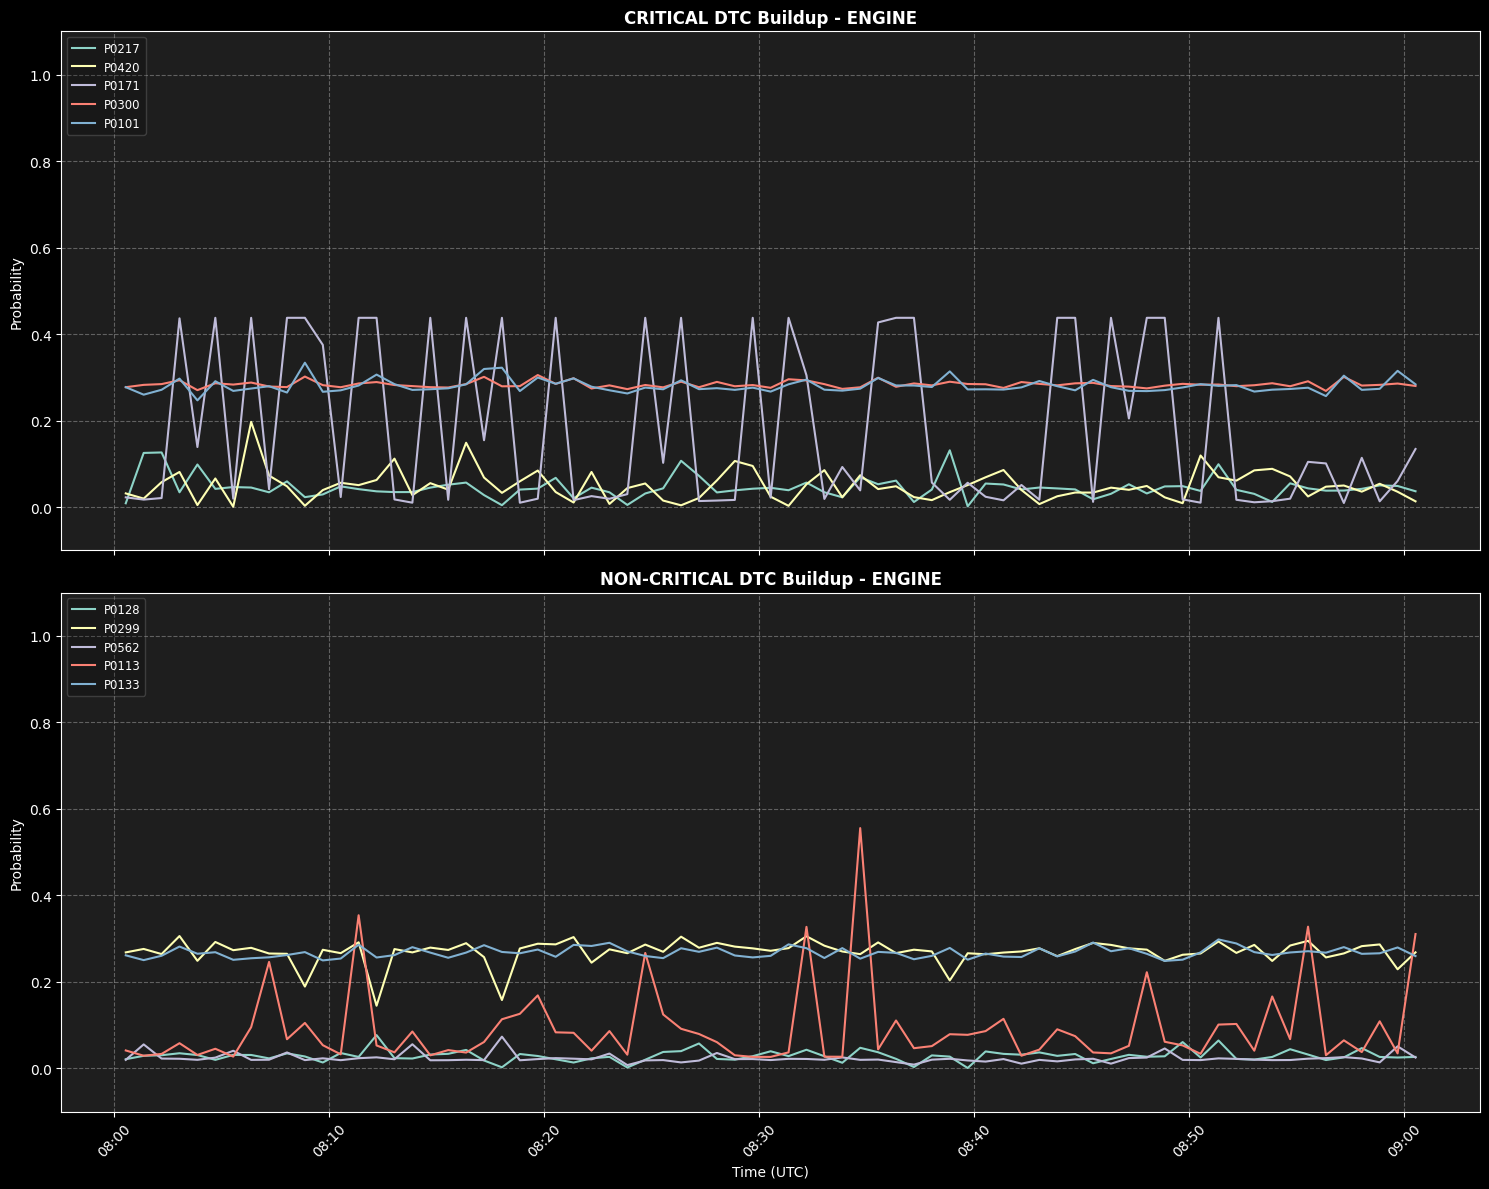

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_dtc_matplotlib(df_res, title, ax):
    """
    Plots DTC probabilities on a given Matplotlib axis.
    """
    # Downsample for performance (Every 50th row)
    df_plot = df_res.iloc[::50].copy()
    
    x_axis = df_plot['timestamp']
    
    # Plot each DTC column
    for col in df_plot.columns:
        if col == 'timestamp': continue
        ax.plot(x_axis, df_plot[col], label=col, linewidth=1.5)

    # Formatting
    ax.set_title(title, fontsize=12, fontweight='bold', color='white')
    ax.set_ylabel("Probability", fontsize=10, color='white')
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc='upper left', fontsize='small', framealpha=0.2)
    
    # Date Formatting on X-Axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.tick_params(axis='x', rotation=45, colors='white')
    ax.tick_params(axis='y', colors='white')
    
    # Dark Background styling
    ax.set_facecolor('#1e1e1e')

# --- Main Plotting Logic ---
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# 1. Critical Plot
plot_dtc_matplotlib(results['critical'], f"CRITICAL DTC Buildup - {MODULE.upper()}", ax1)

# 2. Non-Critical Plot
plot_dtc_matplotlib(results['non_critical'], f"NON-CRITICAL DTC Buildup - {MODULE.upper()}", ax2)

plt.xlabel("Time (UTC)", fontsize=10, color='white')
plt.tight_layout()
plt.show()
     

In [9]:
# 2024-08-01 08:16:32+00:00
# 2024-08-06 15:59:59+00:00

In [10]:
import sys
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
from IPython.display import IFrame, display

# Force install nbformat if you haven't yet
# !{sys.executable} -m pip install nbformat

# Add project root
project_root = Path("C:/streaming_emulator")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Import the Class AND the new function
from DTC.src.inference import DTCInferenceService, apply_smoothing
from DTC.src import config

print("Environment Ready.")
     

ImportError: cannot import name 'apply_smoothing' from 'DTC.src.inference' (C:\streaming_emulator\DTC\src\inference.py)

In [ ]:
# --- USER INPUTS ---
SIM_ID = "sim001"
MODULE = "engine"

# We select a slice of time to analyze. 
# Note: Ensure these timestamps exist in your synthetic_engine_inference...csv file.
# You might need to check your CSV first to pick a valid range.
START_TIME = "2024-08-01 08:00:32+00:00"
END_TIME = "2024-08-01 12:00:32+00:00" # 20 minute window

print(f"Configuration: {SIM_ID} | {MODULE}")
print(f"Window: {START_TIME} -> {END_TIME}")

In [ ]:
def load_data_window(sim_id, module, start_str, end_str):
    search_pattern = config.DATA_DIR / sim_id / f"synthetic_{module}_*.csv"
    import glob
    files = glob.glob(str(search_pattern))
    
    if not files:
        raise FileNotFoundError(f"No CSV found for {module} in {sim_id}")
    
    print(f"Reading: {files[0]}")
    df = pd.read_csv(files[0])
    
    # --- ROBUST TIME HANDLING ---
    # 1. Force the DataFrame column to UTC, handling the "+00:00" automatically
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    
    # 2. Force the Start/End inputs to UTC so they match the DataFrame
    start_ts = pd.to_datetime(start_str, utc=True)
    end_ts = pd.to_datetime(end_str, utc=True)
    
    # 3. Filter
    mask = (df['timestamp'] >= start_ts) & (df['timestamp'] <= end_ts)
    df_window = df.loc[mask].copy()
    
    return df_window

# Execute
try:
    df_window = load_data_window(SIM_ID, MODULE, START_TIME, END_TIME)
    print(f"Successfully loaded {len(df_window)} rows.")
    print("Time range in data:", df_window['timestamp'].min(), "to", df_window['timestamp'].max())
    display(df_window.head(3))
except Exception as e:
    print(f"Error loading data: {e}")

In [ ]:
# 1. Initialize Engine
inference_engine = DTCInferenceService(MODULE)

# 2. Run Inference (Get RAW Zig-Zag Data)
results_raw = inference_engine.analyze_window(df_window)

# 3. Apply Smoothing (Get CLEAN Trend Data)
# We process both Critical and Non-Critical buckets
results_smooth = {
    'critical': apply_smoothing(results_raw['critical'], span=100, noise_gate=0.2),
    'non_critical': apply_smoothing(results_raw['non_critical'], span=100, noise_gate=0.2)
}

print("Inference & Smoothing Complete.")
     

In [ ]:
def create_and_show_plot(df_res, title, filename):
    fig = go.Figure()
    
    # Downsample for performance (Every 50th row)
    df_plot = df_res.iloc[::50].copy()
    x_axis = df_plot['timestamp']
    
    for col in df_plot.columns:
        if col == 'timestamp': continue
        
        fig.add_trace(go.Scatter(
            x=x_axis, 
            y=df_plot[col], 
            mode='lines', 
            name=col
        ))

    fig.update_layout(
        title=title,
        xaxis_title="Time (UTC)",
        yaxis_title="Probability",
        yaxis_range=[-0.05, 1.05], # Lock Y-axis
        template="plotly_dark",
        hovermode="x unified",
        height=500,
        margin=dict(l=20, r=20, t=40, b=20)
    )
    
    # --- SAVE TO FILE (Required for IFrame) ---
    fig.write_html(filename)
    
    print(f"📊 {title}")
    print(f"   -> Saved to: {filename}")
    print(f"   -> To view in new tab: Open {filename} in your browser.")
    
    # --- EMBED IN NOTEBOOK ---
    display(IFrame(src=filename, width="100%", height="550px"))

# --- GENERATE 4 PLOTS ---

# 1. Raw Critical
create_and_show_plot(
    results_raw['critical'], 
    f"RAW Critical DTCs (Noisy) - {MODULE}", 
    "viz_critical_raw.html"
)

# 2. Smooth Critical
create_and_show_plot(
    results_smooth['critical'], 
    f"SMOOTH Critical DTCs (Trend) - {MODULE}", 
    "viz_critical_smooth.html"
)

# 3. Raw Non-Critical
create_and_show_plot(
    results_raw['non_critical'], 
    f"RAW Non-Critical DTCs - {MODULE}", 
    "viz_non_critical_raw.html"
)

# 4. Smooth Non-Critical
create_and_show_plot(
    results_smooth['non_critical'], 
    f"SMOOTH Non-Critical DTCs - {MODULE}", 
    "viz_non_critical_smooth.html"
)
     

In [11]:

import sys
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
from IPython.display import IFrame, display

# Add project root
project_root = Path("C:/streaming_emulator")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Import the new accumulate_risk function
from DTC.src.inference import DTCInferenceService, accumulate_risk
from DTC.src import config

print("Environment Ready. Accumulation logic loaded.")

Environment Ready. Accumulation logic loaded.


In [12]:
# --- USER INPUTS ---
SIM_ID = "sim001"
MODULE = "engine"

# We select a slice of time to analyze. 
# Note: Ensure these timestamps exist in your synthetic_engine_inference...csv file.
# You might need to check your CSV first to pick a valid range.
START_TIME = "2024-08-01 08:00:32+00:00"
END_TIME = "2024-08-01 12:00:32+00:00" # 20 minute window

print(f"Configuration: {SIM_ID} | {MODULE}")
print(f"Window: {START_TIME} -> {END_TIME}")

Configuration: sim001 | engine
Window: 2024-08-01 08:00:32+00:00 -> 2024-08-01 12:00:32+00:00


In [13]:
def load_data_window(sim_id, module, start_str, end_str):
    search_pattern = config.DATA_DIR / sim_id / f"synthetic_{module}_*.csv"
    import glob
    files = glob.glob(str(search_pattern))
    
    if not files:
        raise FileNotFoundError(f"No CSV found for {module} in {sim_id}")
    
    print(f"Reading: {files[0]}")
    df = pd.read_csv(files[0])
    
    # --- ROBUST TIME HANDLING ---
    # 1. Force the DataFrame column to UTC, handling the "+00:00" automatically
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    
    # 2. Force the Start/End inputs to UTC so they match the DataFrame
    start_ts = pd.to_datetime(start_str, utc=True)
    end_ts = pd.to_datetime(end_str, utc=True)
    
    # 3. Filter
    mask = (df['timestamp'] >= start_ts) & (df['timestamp'] <= end_ts)
    df_window = df.loc[mask].copy()
    
    return df_window

# Execute
try:
    df_window = load_data_window(SIM_ID, MODULE, START_TIME, END_TIME)
    print(f"Successfully loaded {len(df_window)} rows.")
    print("Time range in data:", df_window['timestamp'].min(), "to", df_window['timestamp'].max())
    display(df_window.head(3))
except Exception as e:
    print(f"Error loading data: {e}")

Reading: C:\streaming_emulator\data\vehicles\sim001\synthetic_engine_inference_scenarioA_sim001.csv
Successfully loaded 10768 rows.
Time range in data: 2024-08-01 08:00:32+00:00 to 2024-08-01 10:59:59+00:00


,timestamp,date,source_id,air_fuel_ratio_commanded_1,air_fuel_ratio_measured_1,catalyst_temperature_bank_1_sensor_1,catalyst_temperature_bank_1_sensor_2,engine_kw_at_the_wheels_kw,engine_load_absolute,engine_oil_temperature,...,timing_advance,turbo_boost_vacuum_gauge_psi,voltage_control_module_v,volumetric_efficiency_calculated,ecu_7ea_engine_coolant_temperature,ecu_7ea_intake_air_temperature,ecu_7eb_ambient_air_temp,ecu_7eb_engine_load,ecu_7eb_engine_rpm_rpm,ecu_7eb_speed_obd_km_h
486032,2024-08-01 08:00:32+00:00,2024-08-01,sim001,13.321898,14.012035,560.290809,488.530668,0.668211,90.815342,85.417513,...,4.921170,-0.113846,13.429963,43.646081,81.079217,33.291307,34.383778,63.709753,1942.015063,71.694766
486033,2024-08-01 08:00:33+00:00,2024-08-01,sim001,14.088164,14.055989,548.064886,499.736973,0.668211,54.182041,75.730848,...,12.235942,-0.060087,13.290888,48.799936,86.739656,33.075825,40.049087,62.915308,98.462087,73.943680
486034,2024-08-01 08:00:34+00:00,2024-08-01,sim001,13.316015,17.322530,572.332863,432.667877,0.668211,53.156088,79.344319,...,10.644773,-0.048663,13.266764,41.322965,82.058758,32.035983,34.282914,64.504563,1814.357579,66.120053


In [14]:
# 1. Initialize Engine
inference_engine = DTCInferenceService(MODULE)

# 2. Run Inference (Get RAW Zig-Zag Data)
results_raw = inference_engine.analyze_window(df_window)

# 3. Apply Accumulation (The "Bucket" Strategy)
# sensitivity=0.0005 means it takes roughly 2000 "bad frames" to trigger (approx 20 seconds at 100Hz)
# noise_floor=0.20 means any probability below 20% is treated as SAFE.
results_buildup = {
    'critical': accumulate_risk(results_raw['critical'], noise_floor=0.3, sensitivity=0.0002),
    'non_critical': accumulate_risk(results_raw['non_critical'], noise_floor=0.3, sensitivity=0.0002)
}

print("Inference & Accumulation Complete.")

[ENGINE] Loading Artifacts...
   -> Loaded 10 models successfully.
Inference & Accumulation Complete.


In [15]:
# --- HELPER: MAGNIFICATION (AUTO-ZOOM) ---
def magnify_data(df):
    """
    Rescales the dataframe so the HIGHEST peak across ALL columns hits 1.0.
    Preserves relative differences (the winner hits 1.0, losers stay low).
    """
    df_norm = df.copy()
    
    # 1. Identify data columns (exclude timestamp)
    cols = [c for c in df_norm.columns if c != 'timestamp']
    if not cols: return df_norm

    # 2. Find Global Max/Min across the entire dataset
    global_max = df_norm[cols].max().max()
    global_min = df_norm[cols].min().min()
    
    print(f"   -> Magnifying: Peak value {global_max:.4f} stretched to 1.0")
    
    # 3. Safety Check: If data is dead flat (0.0), don't divide by zero
    if (global_max - global_min) < 1e-9:
        return df_norm

    # 4. Apply Global Scaling
    for col in cols:
        df_norm[col] = (df_norm[col] - global_min) / (global_max - global_min)
        
    return df_norm

# --- EXECUTION ---

# 1. Initialize Engine
inference_engine = DTCInferenceService(MODULE)

# 2. Run Inference (Get RAW Zig-Zag Data)
results_raw = inference_engine.analyze_window(df_window)

# 3. Apply Accumulation
results_buildup = {
    'critical': accumulate_risk(results_raw['critical'], noise_floor=0.30, sensitivity=0.0002),
    'non_critical': accumulate_risk(results_raw['non_critical'], noise_floor=0.30, sensitivity=0.0002)
}

# 4. Apply Magnification (Auto-Zoom to 0-1 range)
results_magnified = {
    'critical': magnify_data(results_buildup['critical']),
    'non_critical': magnify_data(results_buildup['non_critical'])
}

print("Inference, Accumulation & Magnification Complete.")
     

[ENGINE] Loading Artifacts...
   -> Loaded 10 models successfully.
   -> Magnifying: Peak value 0.0896 stretched to 1.0
   -> Magnifying: Peak value 0.0313 stretched to 1.0
Inference, Accumulation & Magnification Complete.


In [16]:
def create_and_show_plot(df_res, title, filename, y_label="Probability"):
    fig = go.Figure()
    
    # Downsample for performance (Every 50th row)
    df_plot = df_res.iloc[::50].copy()
    x_axis = df_plot['timestamp']
    
    for col in df_plot.columns:
        if col == 'timestamp': continue
        
        fig.add_trace(go.Scatter(
            x=x_axis, 
            y=df_plot[col], 
            mode='lines', 
            name=col
        ))

    fig.update_layout(
        title=title,
        xaxis_title="Time (UTC)",
        yaxis_title=y_label,
        yaxis_range=[-0.05, 1.05], # Lock Y-axis
        template="plotly_dark",
        hovermode="x unified",
        height=500,
        margin=dict(l=20, r=20, t=40, b=20)
    )
    
    # Save & Embed
    fig.write_html(filename)
    print(f"📊 {title}")
    display(IFrame(src=filename, width="100%", height="550px"))

# --- GENERATE 4 PLOTS (RAW vs MAGNIFIED) ---

# 1. Raw Critical (The Noisy Input)
create_and_show_plot(
    results_raw['critical'], 
    f"RAW Critical DTCs (Input Noise) - {MODULE}", 
    "viz_critical_raw.html",
    y_label="Raw Probability"
)

# 2. Magnified Critical (The Clean Buildup)
create_and_show_plot(
    results_magnified['critical'], 
    f"MAGNIFIED Critical DTCs (Buildup) - {MODULE}", 
    "viz_critical_magnified.html",
    y_label="Risk Score (Norm)"
)

# 3. Raw Non-Critical
create_and_show_plot(
    results_raw['non_critical'], 
    f"RAW Non-Critical DTCs - {MODULE}", 
    "viz_non_critical_raw.html",
    y_label="Raw Probability"
)

# 4. Magnified Non-Critical
create_and_show_plot(
    results_magnified['non_critical'], 
    f"MAGNIFIED Non-Critical DTCs - {MODULE}", 
    "viz_non_critical_magnified.html",
    y_label="Risk Score (Norm)"
)

📊 RAW Critical DTCs (Input Noise) - engine


📊 MAGNIFIED Critical DTCs (Buildup) - engine


📊 RAW Non-Critical DTCs - engine


📊 MAGNIFIED Non-Critical DTCs - engine
